In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()               # click "Choose Files" and pick Resume.csv
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Rows, columns:", df.shape)
print(df.columns.tolist())
df.head()

Saving Resume.csv to Resume (1).csv
Rows, columns: (2484, 4)
['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [2]:
TEXT_COL = "Resume_str"
CATEGORY_COL = "Category"

print(df[CATEGORY_COL].value_counts())
print("\n--- One sample resume (first 800 characters) ---\n")
print(df[TEXT_COL].iloc[0][:800])

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

--- One sample resume (first 800 characters) ---

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management. 

In [3]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def light_clean(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # remove links
    text = re.sub(r"\S+@\S+", " ", text)               # remove emails
    text = re.sub(r"[^a-z0-9+#.\s]", " ", text)        # keep letters, numbers, + # .
    text = re.sub(r"\s+", " ", text).strip()           # fix extra spaces
    return text

def heavy_clean(text):
    text = re.sub(r"[^a-z\s]", " ", text)              # letters only
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(words)

df = df.dropna(subset=[TEXT_COL]).copy()
df["skill_text"] = df[TEXT_COL].apply(light_clean)
df["clean_text"] = df["skill_text"].apply(heavy_clean)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print("Resumes after cleaning:", len(df))
df[[TEXT_COL, "clean_text"]].head(3)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Resumes after cleaning: 2483


,Resume_str,clean_text
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,administrator marketing associate administrato...
1,"HR SPECIALIST, US HR OPERATIONS ...",specialist operations summary versatile media ...
2,HR DIRECTOR Summary Over 2...,director summary years experience recruiting p...


Average skills per resume: 3.3

Example:
  Category                                                   skills_found
0       HR                        [data analysis, leadership, statistics]
1       HR                [communication, networking, project management]
2       HR  [automation, database, excel, leadership, project management]


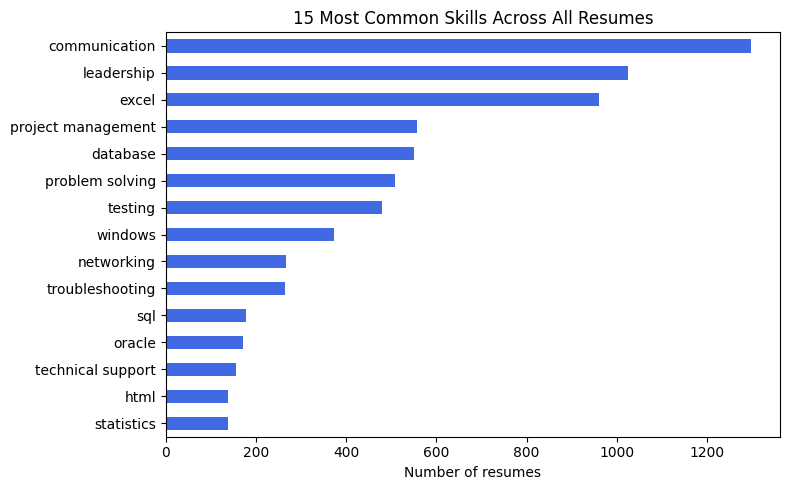

In [5]:
import spacy
from spacy.matcher import PhraseMatcher
from collections import Counter

SKILLS = [
    # programming
    "python", "java", "javascript", "c++", "c#", "sql", "html", "css", "php"
    # data and AI
    "machine learning", "deep learning", "data analysis", "data visualization",
    "statistics", "tensorflow", "pandas", "numpy", "tableau", "power bi", "excel",
    # web and software
    "react", "angular", "node.js", ".net", "django", "flask", "rest api", "git",
    # systems and cloud
    "linux", "windows", "aws", "azure", "docker", "networking", "cybersecurity",
    "database", "mysql", "oracle", "mongodb",
    # tools and process
    "agile", "scrum", "jira", "project management", "troubleshooting",
    "technical support", "testing", "automation",
    # soft skills
    "communication", "leadership", "teamwork", "problem solving",
]

nlp = spacy.blank("en")                      # plain English tokenizer, no download needed
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
matcher.add("SKILLS", [nlp.make_doc(s) for s in SKILLS])

def extract_skills(text):
    doc = nlp.make_doc(text)
    found = {doc[start:end].text.lower() for _, start, end in matcher(doc)}
    return sorted(found)

df["skills_found"] = df["skill_text"].apply(extract_skills)
df["num_skills"] = df["skills_found"].apply(len)

print("Average skills per resume:", round(df["num_skills"].mean(), 1))
print("\nExample:")
print(df[[CATEGORY_COL, "skills_found"]].head(3).to_string())

# Chart: the 15 most common skills
all_skills = Counter(s for lst in df["skills_found"] for s in lst)
top = pd.Series(dict(all_skills.most_common(15)))
top.sort_values().plot(kind="barh", figsize=(8,5), color="royalblue")
plt.title("15 Most Common Skills Across All Resumes")
plt.xlabel("Number of resumes")
plt.tight_layout()
plt.savefig("t3_01_top_skills.png", dpi=150)
plt.show()

In [6]:
jd_text = """
Job Title: IT Support and Systems Engineer
Responsibilities: Provide technical support to users, troubleshoot hardware and
software problems, manage networks and servers, and maintain databases. Work with
the team to resolve issues quickly and document solutions.
Required skills: networking, windows, linux, troubleshooting, technical support, sql
Preferred skills: project management, communication, problem solving, database, aws, azure, testing
"""

jd_lower = jd_text.lower()
req_part = jd_lower.split("required skills:")[1].split("preferred skills:")[0]
pref_part = jd_lower.split("preferred skills:")[1]

required = extract_skills(req_part)
preferred = extract_skills(pref_part)

print("REQUIRED :", required)
print("PREFERRED:", preferred)

jd_clean = heavy_clean(light_clean(jd_text))   # used for text similarity

REQUIRED : ['linux', 'networking', 'sql', 'technical support', 'troubleshooting', 'windows']
PREFERRED: ['aws', 'azure', 'communication', 'database', 'problem solving', 'project management', 'testing']


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1) Text similarity
vec = TfidfVectorizer(ngram_range=(1, 2), max_features=20000)
resume_matrix = vec.fit_transform(df["clean_text"])
jd_vec = vec.transform([jd_clean])
df["text_sim"] = cosine_similarity(jd_vec, resume_matrix).flatten()
df["text_score"] = df["text_sim"] / df["text_sim"].max()     # scale to 0-1

# 2) Weighted skill match
weights = {s: 2 for s in required}
weights.update({s: 1 for s in preferred if s not in weights})
total_weight = sum(weights.values())

def skill_score(found):
    found = set(found)
    return sum(w for s, w in weights.items() if s in found) / total_weight

df["skill_score"] = df["skills_found"].apply(skill_score)

# 3) Final score
df["final_score"] = 0.5 * df["text_score"] + 0.5 * df["skill_score"]

# Sanity check: which job categories are in the top 20 across ALL resumes?
top20 = df.nlargest(20, "final_score")
print("Top 20 resumes by category:")
print(top20[CATEGORY_COL].value_counts())

Top 20 resumes by category:
Category
INFORMATION-TECHNOLOGY    8
CONSULTANT                6
ENGINEERING               3
AVIATION                  1
DIGITAL-MEDIA             1
ADVOCATE                  1
Name: count, dtype: int64


In [9]:
pool = df[df[CATEGORY_COL] == "INFORMATION-TECHNOLOGY"].copy()
pool["missing_required"] = pool["skills_found"].apply(
    lambda f: [s for s in required if s not in f])
pool["missing_preferred"] = pool["skills_found"].apply(
    lambda f: [s for s in preferred if s not in f])

ranked = pool.sort_values("final_score", ascending=False).reset_index(drop=True)
ranked.index = ranked.index + 1          # rank starts at 1

show_cols = ["ID", "final_score", "text_score", "skill_score",
             "skills_found", "missing_required", "missing_preferred"]
ranked[show_cols].head(10).round(2)

,ID,final_score,text_score,skill_score,skills_found,missing_required,missing_preferred
1,46260230,0.88,0.96,0.79,"[communication, cybersecurity, database, leade...",[sql],"[aws, azure]"
2,27295996,0.76,0.88,0.63,"[azure, communication, data analysis, linux, p...","[networking, troubleshooting]","[aws, database, problem solving]"
3,11957080,0.75,0.81,0.68,"[.net, communication, data analysis, database,...",[networking],"[aws, azure, project management, testing]"
4,39413067,0.73,0.78,0.68,"[c#, c++, communication, database, html, java,...","[linux, networking]","[aws, azure]"
5,18301617,0.73,0.62,0.84,"[communication, database, leadership, linux, n...",[],"[aws, azure, problem solving]"
6,22450718,0.70,0.76,0.63,"[communication, database, excel, linux, oracle...","[networking, sql]","[aws, azure, project management]"
7,29051656,0.69,0.64,0.74,"[aws, communication, database, linux, mysql, o...",[networking],"[azure, project management, testing]"
8,28126340,0.66,0.65,0.68,"[.net, css, database, html, javascript, leader...",[troubleshooting],"[aws, azure, communication, problem solving]"
9,90867631,0.65,0.67,0.63,"[automation, c++, communication, database, htm...","[linux, networking]","[aws, azure, problem solving]"
10,17641670,0.64,0.80,0.47,"[automation, communication, excel, html, leade...","[linux, sql, technical support]","[aws, azure, database, problem solving]"


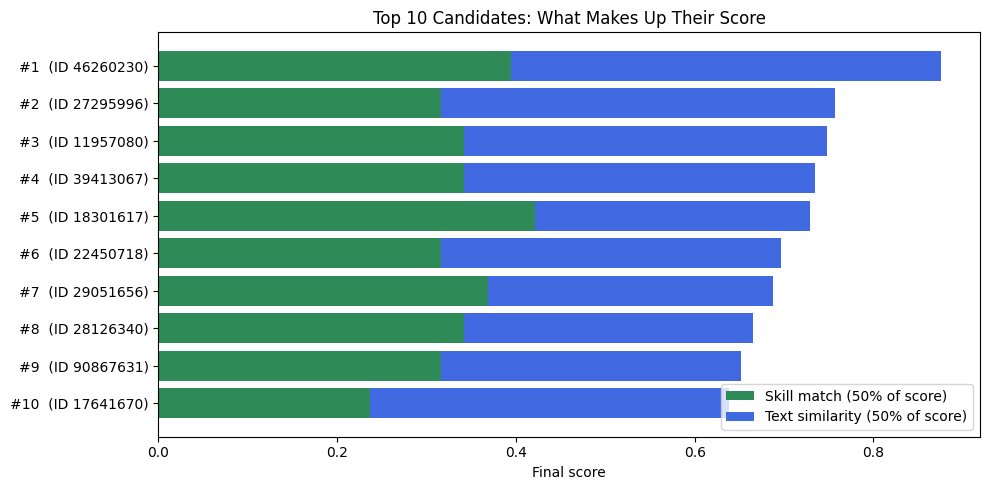

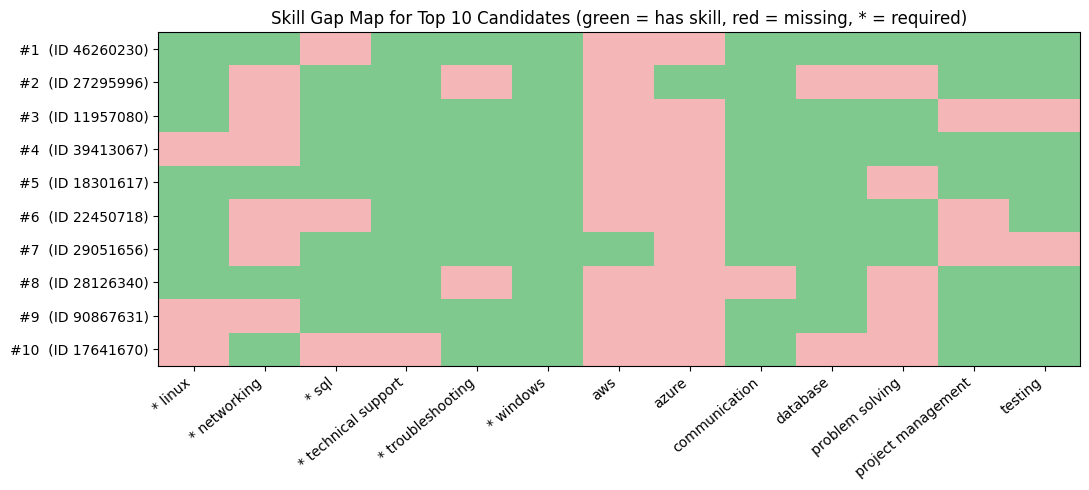

In [10]:
from matplotlib.colors import ListedColormap

top10 = ranked.head(10).copy()
labels = [f"#{i}  (ID {r.ID})" for i, r in top10.iterrows()]

# Chart 2: why each candidate scored what they did
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels, 0.5 * top10["skill_score"], color="seagreen",
        label="Skill match (50% of score)")
ax.barh(labels, 0.5 * top10["text_score"], left=0.5 * top10["skill_score"],
        color="royalblue", label="Text similarity (50% of score)")
ax.invert_yaxis()
ax.set_xlabel("Final score")
ax.set_title("Top 10 Candidates: What Makes Up Their Score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("t3_02_top10_scores.png", dpi=150)
plt.show()

# Chart 3: skill gap map (green = has the skill, red = missing)
skills = required + preferred
matrix = np.array([[1 if s in f else 0 for s in skills]
                   for f in top10["skills_found"]])
skill_labels = [("* " + s) if s in required else s for s in skills]

fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(matrix, cmap=ListedColormap(["#f4b6b6", "#7fc98f"]), aspect="auto")
ax.set_xticks(range(len(skills)))
ax.set_xticklabels(skill_labels, rotation=40, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_title("Skill Gap Map for Top 10 Candidates (green = has skill, red = missing, * = required)")
plt.tight_layout()
plt.savefig("t3_03_skill_gap_map.png", dpi=150)
plt.show()

In [11]:
def explain(rank):
    row = ranked.loc[rank]
    have_req = [s for s in required if s in row["skills_found"]]
    print(f"Rank #{rank} | Candidate ID {row['ID']} | Final score {row['final_score']:.2f}")
    print(f"  Required skills matched : {len(have_req)} of {len(required)}  {have_req}")
    print(f"  Missing required skills : {row['missing_required']}")
    print(f"  Missing preferred skills: {row['missing_preferred']}")
    print(f"  Wording similarity to the job description: "
          f"{row['text_score']:.0%} of the closest resume in the dataset\n")

for r in [1, 2, 3, 10]:
    explain(r)

Rank #1 | Candidate ID 46260230 | Final score 0.88
  Required skills matched : 5 of 6  ['linux', 'networking', 'technical support', 'troubleshooting', 'windows']
  Missing required skills : ['sql']
  Missing preferred skills: ['aws', 'azure']
  Wording similarity to the job description: 96% of the closest resume in the dataset

Rank #2 | Candidate ID 27295996 | Final score 0.76
  Required skills matched : 4 of 6  ['linux', 'sql', 'technical support', 'windows']
  Missing required skills : ['networking', 'troubleshooting']
  Missing preferred skills: ['aws', 'database', 'problem solving']
  Wording similarity to the job description: 88% of the closest resume in the dataset

Rank #3 | Candidate ID 11957080 | Final score 0.75
  Required skills matched : 5 of 6  ['linux', 'sql', 'technical support', 'troubleshooting', 'windows']
  Missing required skills : ['networking']
  Missing preferred skills: ['aws', 'azure', 'project management', 'testing']
  Wording similarity to the job descriptio

In [12]:
def screen_candidates(job_text, category=None, top_n=10):
    """Rank resumes for any job description written in the same format."""
    jd = job_text.lower()
    req = extract_skills(jd.split("required skills:")[1].split("preferred skills:")[0])
    pref = extract_skills(jd.split("preferred skills:")[1])
    wts = {s: 2 for s in req}
    wts.update({s: 1 for s in pref if s not in wts})
    total = sum(wts.values())

    sim = cosine_similarity(
        vec.transform([heavy_clean(light_clean(job_text))]), resume_matrix).flatten()
    out = df.copy()
    out["text_score"] = sim / sim.max()
    out["skill_score"] = out["skills_found"].apply(
        lambda f: sum(w for s, w in wts.items() if s in set(f)) / total)
    out["final_score"] = 0.5 * out["text_score"] + 0.5 * out["skill_score"]
    out["missing_required"] = out["skills_found"].apply(
        lambda f: [s for s in req if s not in f])
    out["missing_preferred"] = out["skills_found"].apply(
        lambda f: [s for s in pref if s not in f])

    if category:
        out = out[out[CATEGORY_COL] == category]
    out = out.sort_values("final_score", ascending=False).head(top_n).reset_index(drop=True)
    out.index = out.index + 1
    return out[["ID", CATEGORY_COL, "final_score", "text_score",
                "skill_score", "missing_required", "missing_preferred"]]

# Save the main result (IT Support role)
result = screen_candidates(jd_text, category="INFORMATION-TECHNOLOGY", top_n=10)
result.round(2).to_csv("top10_candidates.csv")

# Try a DIFFERENT job to prove the system is reusable
dev_jd = """
Job Title: Software Developer
Responsibilities: Build and test web applications, write clean code, work in an
agile team and deploy applications to the cloud.
Required skills: python, java, sql, git, testing
Preferred skills: agile, rest api, docker, aws, communication
"""
screen_candidates(dev_jd, category="INFORMATION-TECHNOLOGY", top_n=5).round(2)

,ID,Category,final_score,text_score,skill_score,missing_required,missing_preferred
1,83816738,INFORMATION-TECHNOLOGY,0.87,1.00,0.73,[python],"[docker, rest api]"
2,20674668,INFORMATION-TECHNOLOGY,0.46,0.39,0.53,[git],"[agile, aws, communication, docker, rest api]"
3,13405733,INFORMATION-TECHNOLOGY,0.43,0.33,0.53,"[git, java]","[aws, docker, rest api]"
4,10265057,INFORMATION-TECHNOLOGY,0.42,0.24,0.60,[git],"[agile, aws, docker, rest api]"
5,70089206,INFORMATION-TECHNOLOGY,0.38,0.36,0.40,"[git, python]","[agile, aws, communication, docker, rest api]"
